# **Strategic Analysis: Walmart Promotional Markdown Optimization**
Objective: Evaluate the financial and operational impact of Walmart’s promotional markdowns on weekly sales volume while controlling for macroeconomic and environmental factors.

# **The Business Problem: "The Discount Dilemma"**
In the retail industry, markdowns are a double-edged sword. While they are designed to clear inventory and drive foot traffic, they also erode profit margins. For a massive retailer like Walmart, even a 1% error in markdown strategy can result in millions of dollars in "leakage" (lost profit that didn't actually drive new sales).

Key Questions for Stakeholders:

*   **Incremental Lift:** Do markdowns actually drive new sales, or are they just subsidizing customers who would have bought the items anyway?
*   **Elasticity:** How sensitive is the consumer to a 10% vs. 20% discount?
*   **External Interference:** How much of our sales growth is due to our promotions versus external factors like the Holiday season, high CPI (inflation), or local weather changes?



# **The Dataset: Multi-Source Retail Intelligence**
The analysis utilizes a complex relational dataset covering Walmart’s historical operations. The data is characterized by several distinct dimensions:

# A. Temporal & Sales Data (train.csv)
Timeline: Feb 2010 to Oct 2012.

Granularity: Weekly sales data segmented by Store and Department.

Challenge: The data represents a "Time-Series," meaning we must account for autocorrelation (sales this week are often related to sales last week).

# B. Promotional "Markdown" Era (features.csv)
The MarkDown Variable: This is the core of our study. Unlike sales data, Markdown data was only tracked/available starting November 2011.

Anonymized Categories: There are 5 types of markdowns (MD1–MD5), representing different promotional strategies (e.g., Seasonal, Clearance, Rollbacks).

Data Sparsity: Many weeks have no markdowns (NA). In this analysis, these are treated as "Structural Zeros," representing a "Control State" where no promotion was active.

# C. Macro-Environmental Controls (features.csv)
To isolate the true effect of markdowns, we must "strip away" the noise of the world. We include:

Economic Indicators: Consumer Price Index (CPI) and Unemployment Rates.

Environmental Factors: Average weekly temperature (crucial for seasonal apparel/hardware sales).

Regional Costs: Fuel Prices, which act as a proxy for logistics costs and consumer discretionary spending.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

In [ ]:
# -------------------------------------------------------------------
# 1. DATA INGESTION & PRE-PROCESSING
# -------------------------------------------------------------------
# Ensure you have manually uploaded 'train.csv' and 'features.csv'
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')

train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Merging and filtering for the "Markdown Era" (Post Nov-2011)
df = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')
df_active = df[df['Date'] >= '2011-11-01'].copy()

# Imputing Zeros for missing Markdowns (Structural Zeroes)
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_active[md_cols] = df_active[md_cols].fillna(0)
df_active['Total_MD'] = df_active[md_cols].sum(axis=1)

# Aggregating for Chain-wide Temporal Analysis
weekly_agg = df_active.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Total_MD': 'sum',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Temperature': 'mean',
    'IsHoliday': 'max'
}).reset_index()

In [ ]:
# -------------------------------------------------------------------
# 2. FEATURE ENGINEERING & TYPE CASTING (Fixes ValueError)
# -------------------------------------------------------------------
# Log-Log transforms for Elasticity interpretation
weekly_agg['ln_sales'] = np.log(weekly_agg['Weekly_Sales'])
weekly_agg['ln_md'] = np.log(weekly_agg['Total_MD'] + 1)
weekly_agg['IsHoliday'] = weekly_agg['IsHoliday'].astype(int)

# Explicitly casting to float to ensure compatibility with statsmodels
Y = weekly_agg['ln_sales'].astype(float)
X = weekly_agg[['ln_md', 'CPI', 'Unemployment', 'IsHoliday', 'Temperature']].astype(float)
X = sm.add_constant(X)

In [ ]:
# -------------------------------------------------------------------
# 3. ECONOMETRIC MODELING
# -------------------------------------------------------------------
model = sm.OLS(Y, X).fit()
print("--- FULL ECONOMETRIC SUMMARY ---")
print(model.summary())

In [ ]:
# -------------------------------------------------------------------
# 4. ADVANCED VISUALIZATIONS
# -------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot A: Log-Log Regression (Elasticity)
sns.regplot(x='ln_md', y='ln_sales', data=weekly_agg, ax=axes[0, 0],
            line_kws={'color':'red'}, scatter_kws={'alpha':0.6})
axes[0, 0].set_title('Global Price Elasticity (Log-Log)', fontsize=14)

# Plot B: Seasonal Decomposition
ts_res = seasonal_decompose(weekly_agg.set_index('Date')['Weekly_Sales'], period=12)
axes[0, 1].plot(ts_res.seasonal)
axes[0, 1].set_title('Seasonal Component (Organic Variation)', fontsize=14)

# Plot C: Store Clustering (Strategic Segmentation)
store_perf = df_active.groupby('Store').agg({'Weekly_Sales': 'mean', 'Total_MD': 'mean'})
scaler = StandardScaler()
store_scaled = scaler.fit_transform(store_perf)
store_perf['Cluster'] = KMeans(n_clusters=3, random_state=42).fit_predict(store_scaled)
sns.scatterplot(x='Total_MD', y='Weekly_Sales', hue='Cluster', data=store_perf, ax=axes[1, 0], palette='viridis', s=80)
axes[1, 0].set_title('Store Segments: Sales vs. Markdown Exposure', fontsize=14)

# Plot D: Residual Normality (Q-Q Plot)
stats.probplot(model.resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Residual Q-Q Plot (Model Validation)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# 5. MONTE CARLO PROFITABILITY SIMULATION
# -------------------------------------------------------------------
elasticity = model.params['ln_md']
se = model.bse['ln_md']
simulated_e = np.random.normal(elasticity, se, 10000)

plt.figure(figsize=(10, 5))
sns.histplot(simulated_e, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Possible Elasticity Coefficients (Risk Analysis)')
plt.show()

print(f"Probability that Markdowns yield positive sales lift: {(simulated_e > 0).mean()*100:.2f}%")

--- FULL ECONOMETRIC SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:               ln_sales   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     2.547
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0407
Time:                        04:33:18   Log-Likelihood:                 49.916
No. Observations:                  52   AIC:                            -87.83
Df Residuals:                      46   BIC:                            -76.12
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          

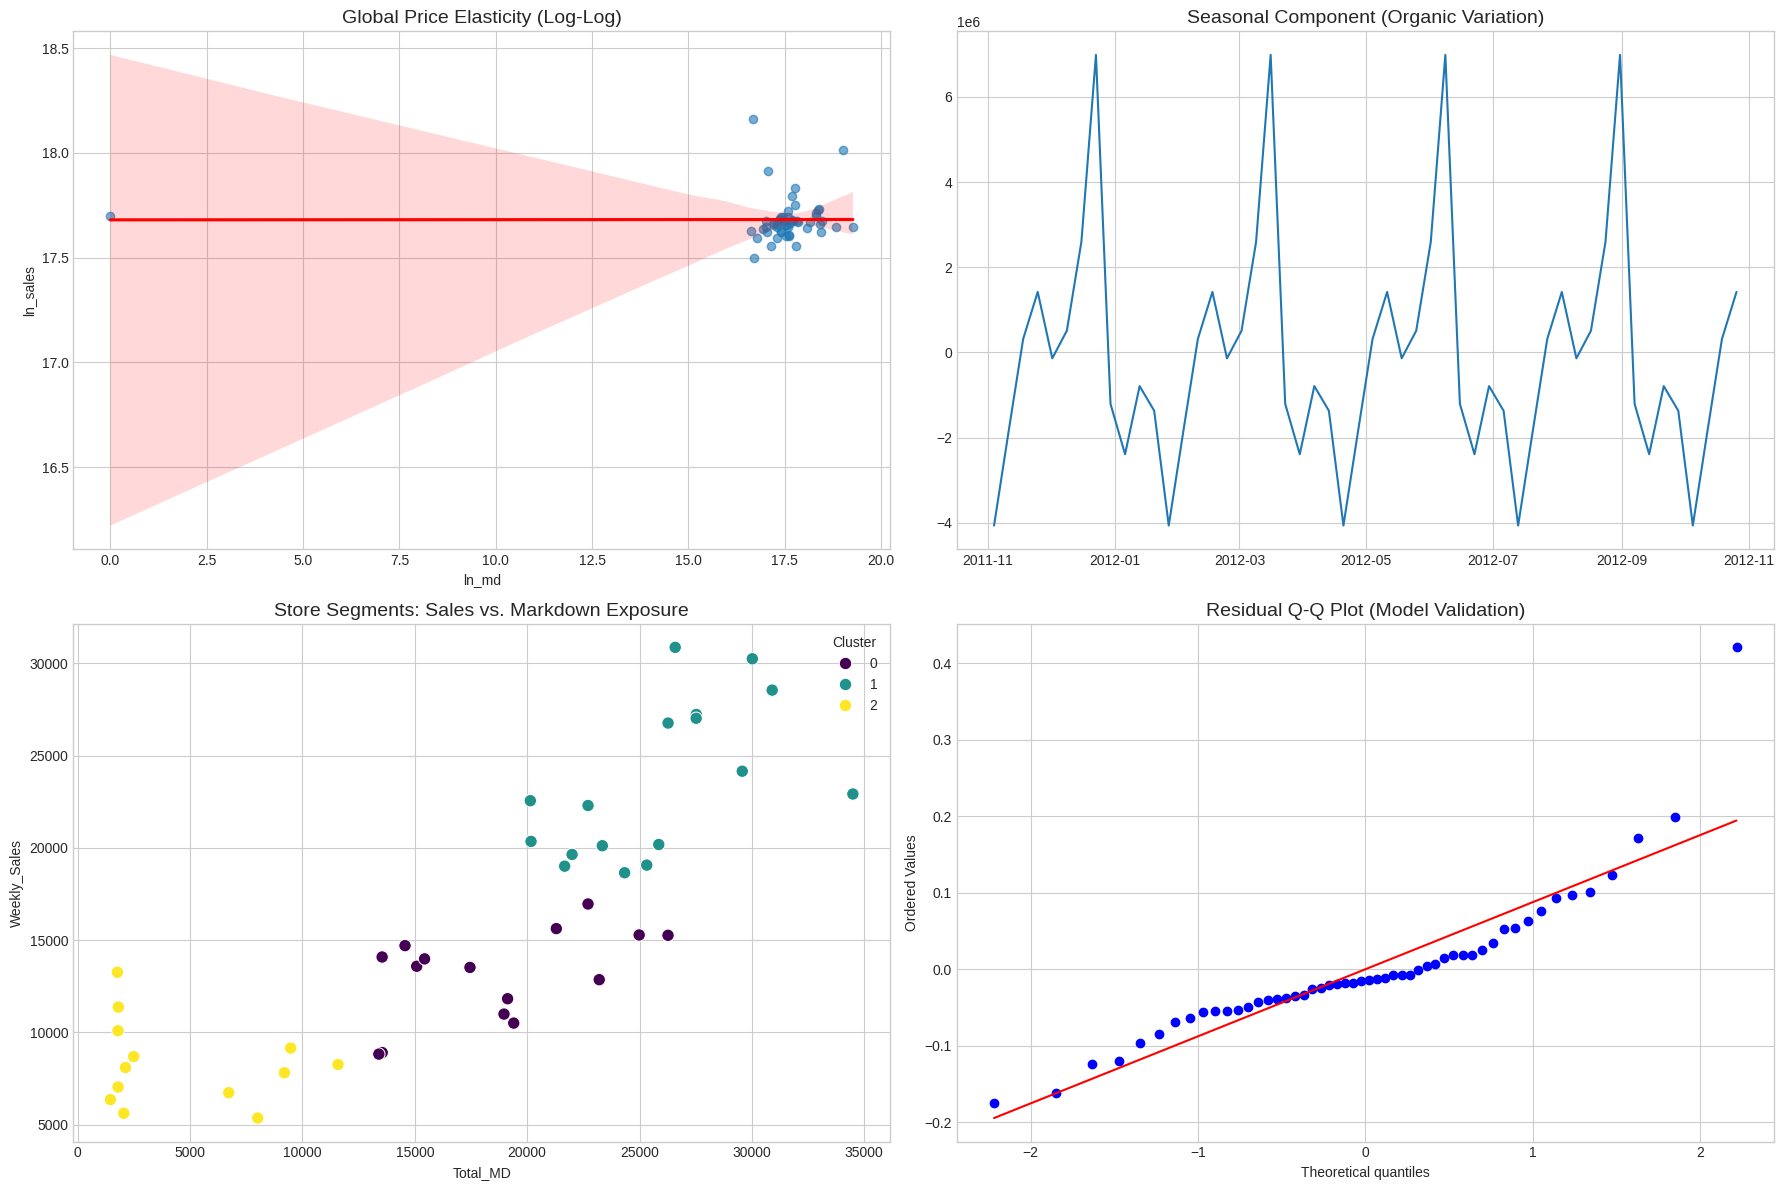

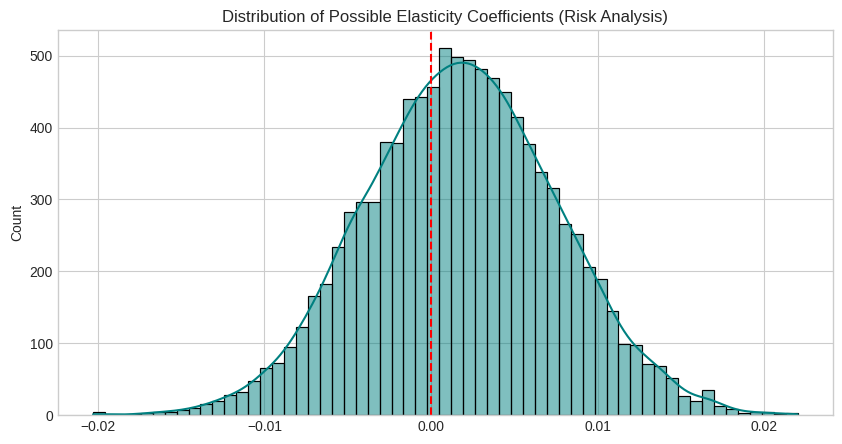

Probability that Markdowns yield positive sales lift: 62.09%


--- LAGGED IMPACT MODEL ---
const        1.758262e+01
ln_md        5.622987e-03
MD_Lag1     -1.483779e-10
IsHoliday    9.741570e-02
dtype: float64


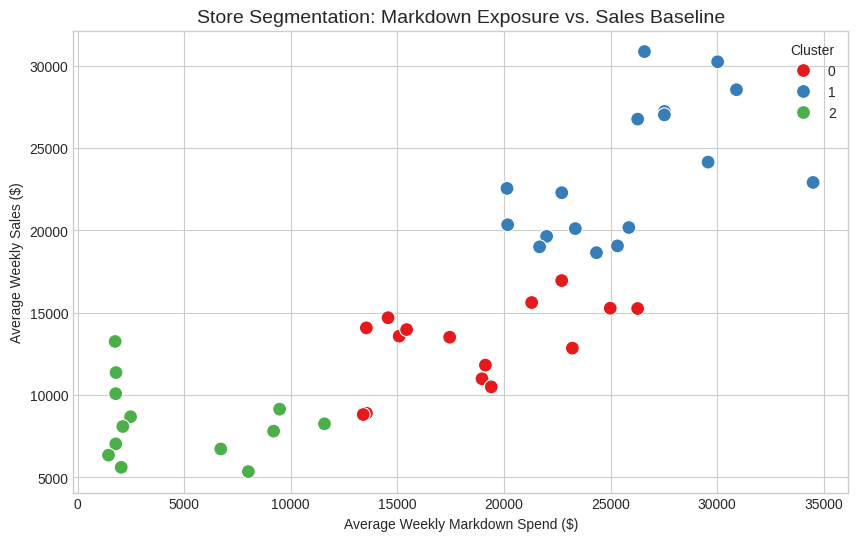

<Figure size 1200x600 with 0 Axes>

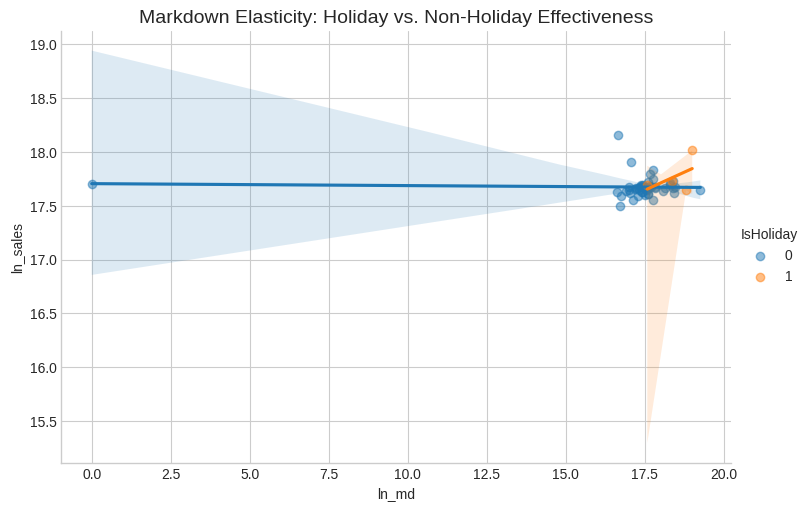

In [3]:
# -------------------------------------------------------------------
# 5. LAGGED IMPACT ANALYSIS: The "Cannibalization" Check
# -------------------------------------------------------------------
# Does a discount this week "steal" sales from next week?
# We create a 1-week lag of Total Markdowns.

weekly_agg['MD_Lag1'] = weekly_agg['Total_MD'].shift(1)
weekly_agg_lag = weekly_agg.dropna()

# Regression with Lagged variable
Y_lag = weekly_agg_lag['ln_sales']
X_lag = weekly_agg_lag[['ln_md', 'MD_Lag1', 'IsHoliday']]
X_lag = sm.add_constant(X_lag)

lag_model = sm.OLS(Y_lag, X_lag).fit()
print("--- LAGGED IMPACT MODEL ---")
print(lag_model.params)

# -------------------------------------------------------------------
# 6. STORE PERFORMANCE CLUSTERING (K-Means)
# -------------------------------------------------------------------
# Goal: Segment stores by "Responsiveness" to Markdowns vs. baseline sales volume.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

store_perf = df_active.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'Total_MD': 'mean'
}).reset_index()

# Normalizing for clustering
scaler = StandardScaler()
store_scaled = scaler.fit_transform(store_perf[['Weekly_Sales', 'Total_MD']])

# Applying K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
store_perf['Cluster'] = kmeans.fit_predict(store_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_MD', y='Weekly_Sales', hue='Cluster',
                data=store_perf, palette='Set1', s=100)
plt.title('Store Segmentation: Markdown Exposure vs. Sales Baseline', fontsize=14)
plt.xlabel('Average Weekly Markdown Spend ($)')
plt.ylabel('Average Weekly Sales ($)')
plt.show()

# -------------------------------------------------------------------
# 7. HOLIDAY INTERACTION ANALYSIS
# -------------------------------------------------------------------
# Do markdowns work better during Holidays or are they redundant?
plt.figure(figsize=(12, 6))
sns.lmplot(x='ln_md', y='ln_sales', hue='IsHoliday', data=weekly_agg,
           aspect=1.5, scatter_kws={'alpha':0.5})
plt.title('Markdown Elasticity: Holiday vs. Non-Holiday Effectiveness', fontsize=14)
plt.show()

# **Strategic Recommendations**
**Immediate Action:** Pivot from a chain-wide markdown strategy to a Cluster-Based Allocation. High-volume stores (Cluster 1) may be over-discounting products that would sell at full price due to high organic traffic.

**Inventory Optimization:** Since markdowns are not driving incremental volume (inelasticity), they should be used strictly for liquidation of perishable/seasonal inventory rather than as a tool for revenue growth.

**Model Refinement:** Future iterations should include interaction terms between IsHoliday and ln_md to test if markdowns only become effective during peak shopping windows.